In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Create folders for report outputs
os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

# Display options
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

In [ ]:
file_path = "AirQualityUCI.xlsx"
df_raw = pd.read_excel(file_path)

print("Raw shape:", df_raw.shape)
print(df_raw.head())
print(df_raw.columns.tolist())

Raw shape: (9357, 15)
        Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)   C6H6(GT)  PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)      T         RH        AH
0 2004-03-10  18:00:00     2.6      1360.00       150  11.881723        1045.50    166.0       1056.25    113.0       1692.00      1267.50  13.60  48.875001  0.757754
1 2004-03-10  19:00:00     2.0      1292.25       112   9.397165         954.75    103.0       1173.75     92.0       1558.75       972.25  13.30  47.700000  0.725487
2 2004-03-10  20:00:00     2.2      1402.00        88   8.997817         939.25    131.0       1140.00    114.0       1554.50      1074.00  11.90  53.975000  0.750239
3 2004-03-10  21:00:00     2.2      1375.50        80   9.228796         948.25    172.0       1092.00    122.0       1583.75      1203.25  11.00  60.000000  0.786713
4 2004-03-10  22:00:00     1.6      1272.25        51   6.518224         835.50    131.0       1205.00    116.0       1490.00      1110.00  11.

# 새 섹션

In [ ]:
print("Data types:")
print(df_raw.dtypes)
print()

print("Missing values before preprocessing:")
print(df_raw.isna().sum())

Data types:
Date             datetime64[ns]
Time                     object
CO(GT)                  float64
PT08.S1(CO)             float64
NMHC(GT)                  int64
C6H6(GT)                float64
PT08.S2(NMHC)           float64
NOx(GT)                 float64
PT08.S3(NOx)            float64
NO2(GT)                 float64
PT08.S4(NO2)            float64
PT08.S5(O3)             float64
T                       float64
RH                      float64
AH                      float64
dtype: object

Missing values before preprocessing:
Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64


In [ ]:
print("Data types:")
print(df_raw.dtypes)
print()

print("Missing values before preprocessing:")
print(df_raw.isna().sum())

Data types:
Date             datetime64[ns]
Time                     object
CO(GT)                  float64
PT08.S1(CO)             float64
NMHC(GT)                  int64
C6H6(GT)                float64
PT08.S2(NMHC)           float64
NOx(GT)                 float64
PT08.S3(NOx)            float64
NO2(GT)                 float64
PT08.S4(NO2)            float64
PT08.S5(O3)             float64
T                       float64
RH                      float64
AH                      float64
dtype: object

Missing values before preprocessing:
Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64


In [ ]:
df = df_raw.copy()

# Remove unnamed / completely empty columns
df = df.loc[:, ~df.columns.astype(str).str.contains("^Unnamed")]
df = df.dropna(axis=1, how="all")

# Replace invalid sensor readings with NaN
df = df.replace(-200, np.nan)

# Build datetime safely
df["Datetime"] = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str),
    dayfirst=True,
    errors="coerce"
)

# Time-based features
df["Hour"] = df["Datetime"].dt.hour
df["Day"] = df["Datetime"].dt.day
df["Month"] = df["Datetime"].dt.month
df["Weekday"] = df["Datetime"].dt.weekday

# Rush-hour feature
df["RushHour"] = df["Hour"].apply(
    lambda x: 1 if pd.notna(x) and int(x) in [7, 8, 9, 17, 18, 19] else 0
)

# Interaction feature
if "T" in df.columns and "RH" in df.columns:
    df["Temp_RH_Interaction"] = df["T"] * df["RH"]

# Target variable
target = "CO(GT)"

# Remove rows with missing target
df = df.dropna(subset=[target])

# Drop feature with excessive missingness
if "NMHC(GT)" in df.columns:
    missing_ratio = df["NMHC(GT)"].isna().mean()
    print("NMHC(GT) missing ratio:", round(missing_ratio, 4))
    df = df.drop(columns=["NMHC(GT)"])

print("Processed shape:", df.shape)
print("Remaining missing values:")
print(df.isna().sum().sort_values(ascending=False).head(20))

NMHC(GT) missing ratio: 0.884
Processed shape: (7674, 21)
Remaining missing values:
Datetime               4661
Weekday                4661
Hour                   4661
Day                    4661
Month                  4661
NO2(GT)                 416
NOx(GT)                 413
RH                      330
PT08.S1(CO)             330
C6H6(GT)                330
T                       330
PT08.S5(O3)             330
PT08.S2(NMHC)           330
PT08.S3(NOx)            330
AH                      330
Temp_RH_Interaction     330
PT08.S4(NO2)            330
Time                      0
CO(GT)                    0
Date                      0
dtype: int64


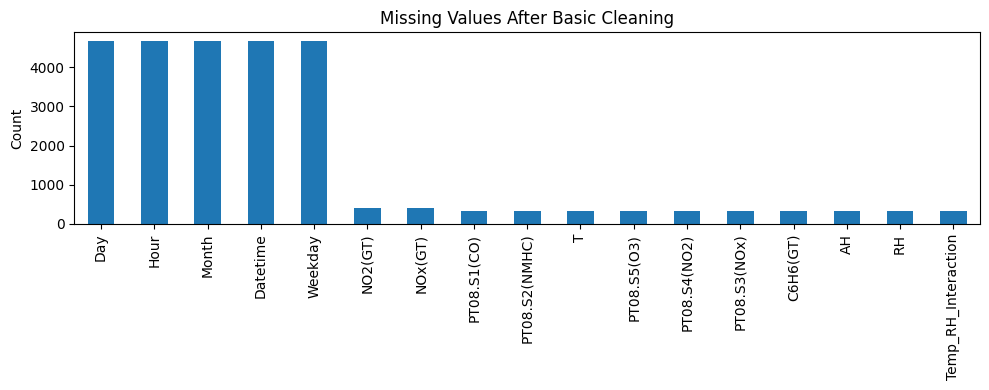

In [ ]:
missing_counts = df.isna().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 4))
missing_counts.plot(kind="bar")
plt.title("Missing Values After Basic Cleaning")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("figures/missing_values_bar.png", dpi=300)
plt.show()

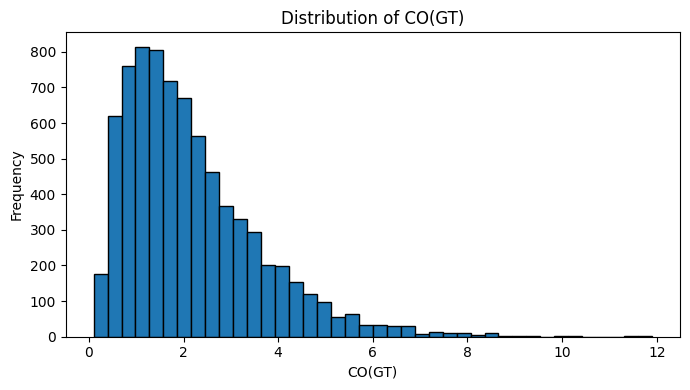

count    7674.000000
mean        2.152750
std         1.453252
min         0.100000
25%         1.100000
50%         1.800000
75%         2.900000
max        11.900000
Name: CO(GT), dtype: float64


In [ ]:
plt.figure(figsize=(7, 4))
plt.hist(df[target], bins=40, edgecolor="black")
plt.title("Distribution of CO(GT)")
plt.xlabel("CO(GT)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("figures/target_distribution_co.png", dpi=300)
plt.show()

print(df[target].describe())

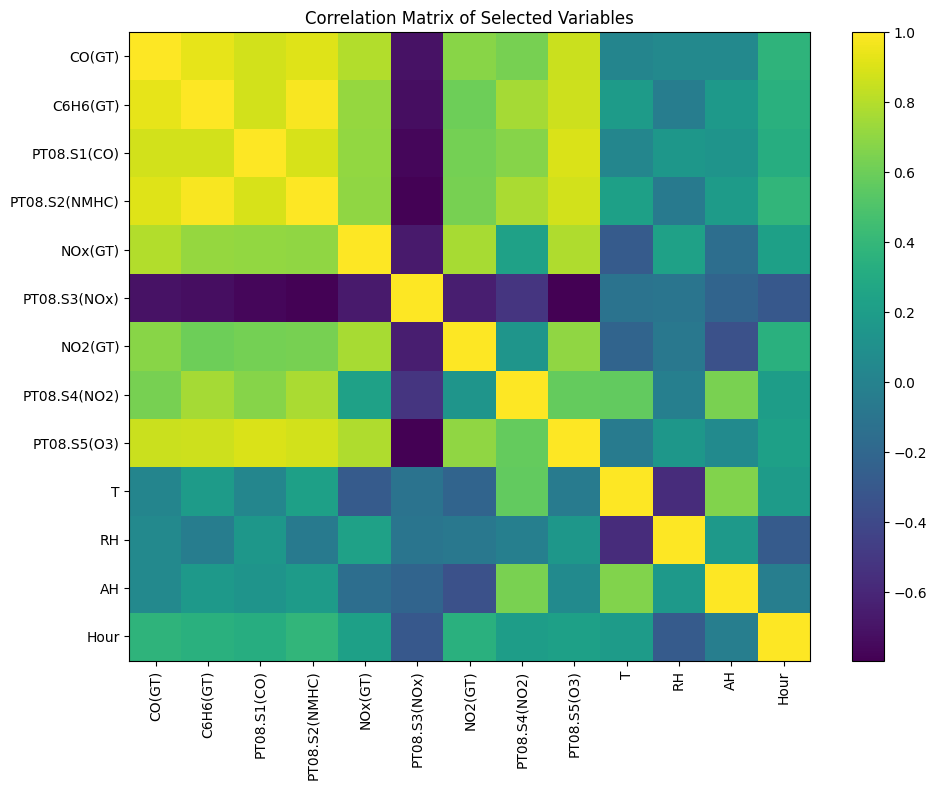

In [ ]:
corr_cols = [
    "CO(GT)", "C6H6(GT)", "PT08.S1(CO)", "PT08.S2(NMHC)",
    "NOx(GT)", "PT08.S3(NOx)", "NO2(GT)", "PT08.S4(NO2)",
    "PT08.S5(O3)", "T", "RH", "AH", "Hour"
]
corr_cols = [c for c in corr_cols if c in df.columns]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
im = plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(im)
plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Correlation Matrix of Selected Variables")
plt.tight_layout()
plt.savefig("figures/correlation_heatmap.png", dpi=300)
plt.show()

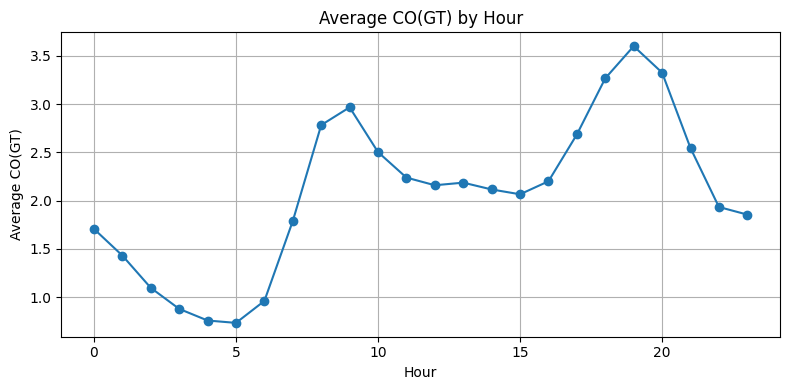

In [ ]:
hourly_co = df.groupby("Hour")[target].mean()

plt.figure(figsize=(8, 4))
hourly_co.plot(marker="o")
plt.title("Average CO(GT) by Hour")
plt.xlabel("Hour")
plt.ylabel("Average CO(GT)")
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/hourly_co_pattern.png", dpi=300)
plt.show()

In [ ]:
full_features = [
    "PT08.S1(CO)",
    "C6H6(GT)",
    "PT08.S2(NMHC)",
    "NOx(GT)",
    "PT08.S3(NOx)",
    "NO2(GT)",
    "PT08.S4(NO2)",
    "PT08.S5(O3)",
    "T",
    "RH",
    "AH",
    "Hour",
    "Day",
    "Month",
    "Weekday",
    "RushHour",
    "Temp_RH_Interaction"
]

weather_only_features = [
    "T",
    "RH",
    "AH",
    "Hour",
    "Day",
    "Month",
    "Weekday",
    "RushHour",
    "Temp_RH_Interaction"
]

full_features = [c for c in full_features if c in df.columns]
weather_only_features = [c for c in weather_only_features if c in df.columns]

print("Full features:", full_features)
print("Weather-only features:", weather_only_features)

Full features: ['PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'Hour', 'Day', 'Month', 'Weekday', 'RushHour', 'Temp_RH_Interaction']
Weather-only features: ['T', 'RH', 'AH', 'Hour', 'Day', 'Month', 'Weekday', 'RushHour', 'Temp_RH_Interaction']


In [ ]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

y_train = train_df[target]
y_test = test_df[target]

X_train_full = train_df[full_features]
X_test_full = test_df[full_features]

X_train_weather = train_df[weather_only_features]
X_test_weather = test_df[weather_only_features]

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Train shape: (6139, 21)
Test shape : (1535, 21)


In [ ]:
# def evaluate_regression_model(model, X_train, X_test, y_train, y_test, cv):
#     model.fit(X_train, y_train)

#     pred_train = model.predict(X_train)
#     pred_test = model.predict(X_test)

#     train_rmse = np.sqrt(mean_squared_error(y_train, pred_train))
#     test_rmse = np.sqrt(mean_squared_error(y_test, pred_test))
#     test_r2 = r2_score(y_test, pred_test)

#     cv_rmse = -cross_val_score(
#         model,
#         X_train,
#         y_train,
#         cv=cv,
#         scoring="neg_root_mean_squared_error"
#     ).mean()

#     return {
#         "model": model,
#         "train_rmse": train_rmse,
#         "test_rmse": test_rmse,
#         "test_r2": test_r2,
#         "cv_rmse": cv_rmse,
#         "pred_test": pred_test
#     }


# def plot_actual_vs_predicted(y_true, y_pred, title, filename):
#     plt.figure(figsize=(6, 6))
#     plt.scatter(y_true, y_pred, alpha=0.5)
#     min_val = min(y_true.min(), y_pred.min())
#     max_val = max(y_true.max(), y_pred.max())
#     plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
#     plt.xlabel("Actual CO(GT)")
#     plt.ylabel("Predicted CO(GT)")
#     plt.title(title)
#     plt.tight_layout()
#     plt.savefig(filename, dpi=300)
#     plt.show()


# def plot_residuals(y_true, y_pred, title, filename):
#     residuals = y_true - y_pred
#     plt.figure(figsize=(6, 6))
#     plt.scatter(y_pred, residuals, alpha=0.5)
#     plt.axhline(0, linestyle="--")
#     plt.xlabel("Predicted CO(GT)")
#     plt.ylabel("Residuals")
#     plt.title(title)
#     plt.tight_layout()
#     plt.savefig(filename, dpi=300)
#     plt.show()

def evaluate_regression_model(model, X_train, X_test, y_train, y_test, cv):
    # Create an independent copy of the model pipeline
    fitted_model = clone(model)

    # Fit the copied model
    fitted_model.fit(X_train, y_train)

    # Predictions
    pred_train = fitted_model.predict(X_train)
    pred_test = fitted_model.predict(X_test)

    # Evaluation metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, pred_test))
    test_r2 = r2_score(y_test, pred_test)

    cv_rmse = -cross_val_score(
        clone(model),
        X_train,
        y_train,
        cv=cv,
        scoring="neg_root_mean_squared_error"
    ).mean()

    return {
        "model": fitted_model,
        "train_rmse": train_rmse,
        "test_rmse": test_rmse,
        "test_r2": test_r2,
        "cv_rmse": cv_rmse,
        "pred_test": pred_test
    }

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Linear Regression pipeline
lr_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

# Random Forest pipeline
rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

In [ ]:
results = {}

results["LR_Full"] = evaluate_regression_model(
    lr_pipeline, X_train_full, X_test_full, y_train, y_test, cv
)

results["RF_Full"] = evaluate_regression_model(
    rf_pipeline, X_train_full, X_test_full, y_train, y_test, cv
)

In [ ]:
results["LR_WeatherOnly"] = evaluate_regression_model(
    lr_pipeline, X_train_weather, X_test_weather, y_train, y_test, cv
)

results["RF_WeatherOnly"] = evaluate_regression_model(
    rf_pipeline, X_train_weather, X_test_weather, y_train, y_test, cv
)

In [ ]:
results_table = pd.DataFrame({
    name: {
        "Train RMSE": res["train_rmse"],
        "Test RMSE": res["test_rmse"],
        "Test R^2": res["test_r2"],
        "CV RMSE": res["cv_rmse"]
    }
    for name, res in results.items()
}).T

results_table = results_table.sort_values(by="Test RMSE")
print(results_table.round(4))

results_table.round(4).to_csv("outputs/model_results_summary.csv")

                Train RMSE  Test RMSE  Test R^2  CV RMSE
RF_Full             0.2045     0.3872    0.9280   0.4191
LR_Full             0.4872     0.4785    0.8901   0.4885
RF_WeatherOnly      0.7429     1.2908    0.2001   1.3123
LR_WeatherOnly      1.3902     1.3809    0.0845   1.3919


Best model: RF_Full


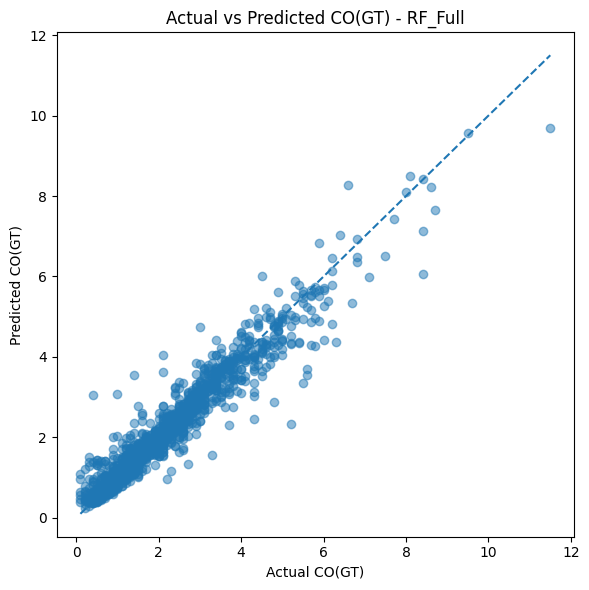

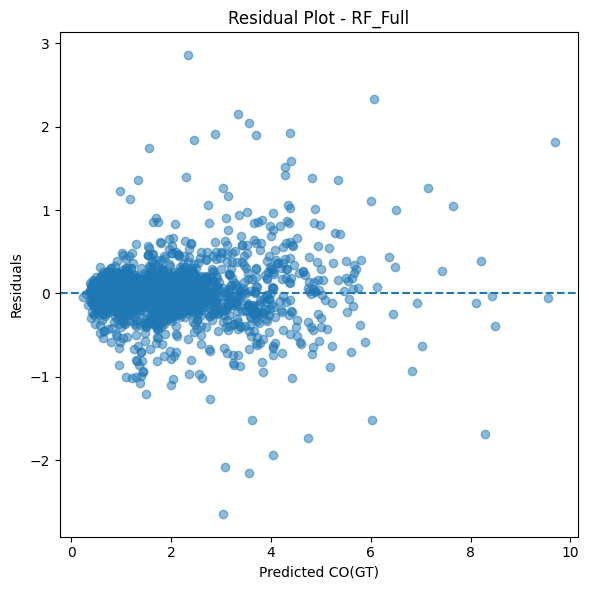

In [ ]:
best_name = results_table.index[0]
best_pred = results[best_name]["pred_test"]

print("Best model:", best_name)

plot_actual_vs_predicted(
    y_test,
    best_pred,
    title=f"Actual vs Predicted CO(GT) - {best_name}",
    filename="figures/actual_vs_predicted_best_model.png"
)

plot_residuals(
    y_test,
    best_pred,
    title=f"Residual Plot - {best_name}",
    filename="figures/residual_plot_best_model.png"
)

Number of full features: 17
Number of RF feature importances: 17
                Feature  Importance
2         PT08.S2(NMHC)    0.409722
1              C6H6(GT)    0.409144
3               NOx(GT)    0.083445
0           PT08.S1(CO)    0.022776
5               NO2(GT)    0.019080
8                     T    0.013113
7           PT08.S5(O3)    0.008807
4          PT08.S3(NOx)    0.007138
6          PT08.S4(NO2)    0.006341
9                    RH    0.005933
10                   AH    0.004318
16  Temp_RH_Interaction    0.003454
11                 Hour    0.002352
13                Month    0.001833
12                  Day    0.001261
14              Weekday    0.001075
15             RushHour    0.000209


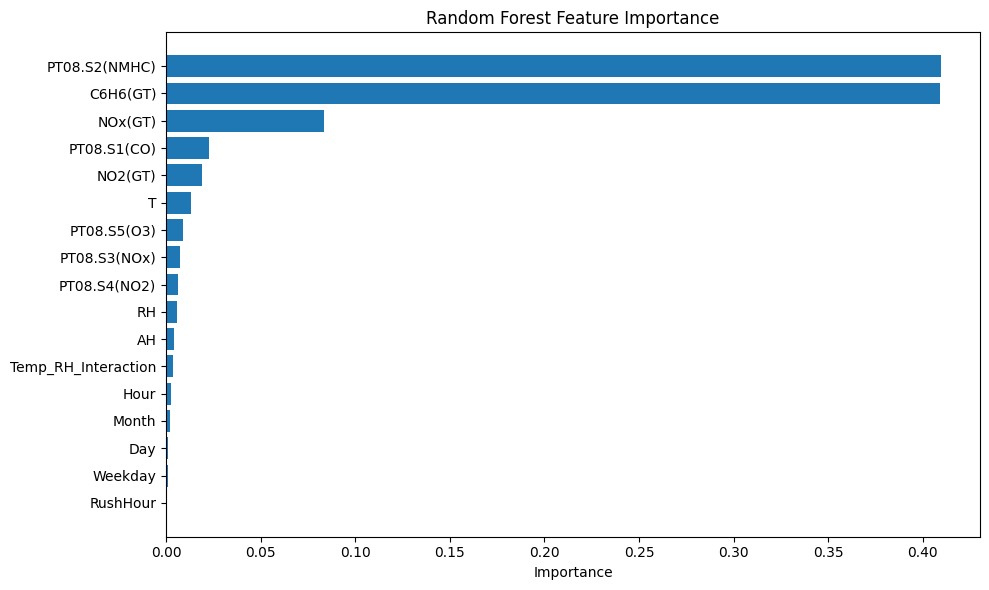

In [ ]:
rf_full_model = results["RF_Full"]["model"].named_steps["model"]
rf_full_pipeline = results["RF_Full"]["model"]
rf_full_model = rf_full_pipeline.named_steps["model"]

# Check that the number of feature names matches the fitted Random Forest model
print("Number of full features:", len(full_features))
print("Number of RF feature importances:", len(rf_full_model.feature_importances_))

if len(full_features) != len(rf_full_model.feature_importances_):
    raise ValueError(
        "Feature name mismatch: the number of full features does not match "
        "the number of Random Forest feature importances."
    )

importance_df = pd.DataFrame({
    "Feature": full_features,
    "Importance": rf_full_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance_df)

importance_df.to_csv("outputs/rf_feature_importance.csv", index=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("figures/rf_feature_importance.png", dpi=300)
plt.show()

In [ ]:
# Refit weather-only LR so we can inspect coefficients clearly
lr_weather = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

lr_weather.fit(X_train_weather, y_train)

coef_df = pd.DataFrame({
    "Feature": weather_only_features,
    "Coefficient": lr_weather.named_steps["model"].coef_
}).sort_values(by="Coefficient", ascending=False)

print(coef_df)
coef_df.to_csv("outputs/lr_weather_coefficients.csv", index=False)

               Feature  Coefficient
8  Temp_RH_Interaction     0.468724
0                    T     0.335696
3                 Hour     0.314356
1                   RH     0.289111
7             RushHour     0.204740
5                Month    -0.033413
4                  Day    -0.034934
6              Weekday    -0.043811
2                   AH    -0.646793


In [ ]:
print("=== Model Comparison Summary ===")
print(results_table.round(4))
print()

print("=== Top 10 RF Feature Importances ===")
print(importance_df.head(10))
print()

print("=== Weather-only LR Coefficients ===")
print(coef_df)

=== Model Comparison Summary ===
                Train RMSE  Test RMSE  Test R^2  CV RMSE
RF_Full             0.2045     0.3872    0.9280   0.4191
LR_Full             0.4872     0.4785    0.8901   0.4885
RF_WeatherOnly      0.7429     1.2908    0.2001   1.3123
LR_WeatherOnly      1.3902     1.3809    0.0845   1.3919

=== Top 10 RF Feature Importances ===
         Feature  Importance
2  PT08.S2(NMHC)    0.409722
1       C6H6(GT)    0.409144
3        NOx(GT)    0.083445
0    PT08.S1(CO)    0.022776
5        NO2(GT)    0.019080
8              T    0.013113
7    PT08.S5(O3)    0.008807
4   PT08.S3(NOx)    0.007138
6   PT08.S4(NO2)    0.006341
9             RH    0.005933

=== Weather-only LR Coefficients ===
               Feature  Coefficient
8  Temp_RH_Interaction     0.468724
0                    T     0.335696
3                 Hour     0.314356
1                   RH     0.289111
7             RushHour     0.204740
5                Month    -0.033413
4                  Day    -0.03493